In [1]:
# 🔹 CELDA 1: Introducción a NLP

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import re
from collections import Counter

print("=" * 60)
print("SEMANA 10: NLP - PROCESAMIENTO DE LENGUAJE NATURAL")
print("=" * 60)

print("""
¿QUÉ HACE ESTA CELDA?
Explica qué es NLP, por qué es diferente a visión,
y cuál es el desafío principal.

DIFERENCIA NLP vs VISIÓN:

Visión (CNN):           NLP (RNN/Transformers):
Píxeles → números      Palabras → significado
Orden: menos crítico    Orden: CRÍTICO
"gato" es número       "gato" vs "taco" = DIFERENTES

DESAFÍO NLP:
- Palabras son categorías (no números)
- Orden importa: "A comió B" ≠ "B comió A"
- Contexto: "banco" = río vs dinero
- Semántica: "grande" y "enorme" = parecidos

PIPELINE NLP BÁSICO:
Texto → Tokenización → Embeddings → Modelo → Salida
"hola mundo" → ["hola", "mundo"] → [0.2, 0.5], [0.1, 0.3] → Clasificación
""")

print("""
CONCEPTOS CLAVE:

1. TOKENIZACIÓN: Dividir texto en palabras
   "Hola mundo" → ["Hola", "mundo"]

2. EMBEDDING: Convertir palabra a vector
   "gato" → [0.2, 0.5, -0.1, ...]
   Palabras similares = vectores cercanos

3. RNN/LSTM: Procesa secuencia de palabras
   [emb("el"), emb("gato")] → Significado

4. CLASIFICACIÓN: Salida final
   Texto → Sentimiento (positivo/negativo)
   Texto → Tema (deporte/política/tecnología)
""")


SEMANA 10: NLP - PROCESAMIENTO DE LENGUAJE NATURAL

¿QUÉ HACE ESTA CELDA?
Explica qué es NLP, por qué es diferente a visión,
y cuál es el desafío principal.

DIFERENCIA NLP vs VISIÓN:

Visión (CNN):           NLP (RNN/Transformers):
Píxeles → números      Palabras → significado
Orden: menos crítico    Orden: CRÍTICO
"gato" es número       "gato" vs "taco" = DIFERENTES

DESAFÍO NLP:
- Palabras son categorías (no números)
- Orden importa: "A comió B" ≠ "B comió A"
- Contexto: "banco" = río vs dinero
- Semántica: "grande" y "enorme" = parecidos

PIPELINE NLP BÁSICO:
Texto → Tokenización → Embeddings → Modelo → Salida
"hola mundo" → ["hola", "mundo"] → [0.2, 0.5], [0.1, 0.3] → Clasificación


CONCEPTOS CLAVE:

1. TOKENIZACIÓN: Dividir texto en palabras
   "Hola mundo" → ["Hola", "mundo"]

2. EMBEDDING: Convertir palabra a vector
   "gato" → [0.2, 0.5, -0.1, ...]
   Palabras similares = vectores cercanos

3. RNN/LSTM: Procesa secuencia de palabras
   [emb("el"), emb("gato")] → Significado



In [2]:
# 🔹 CELDA 2: Tokenización y Vocabulario

print("\n" + "=" * 60)
print("TOKENIZACIÓN Y VOCABULARIO")
print("=" * 60)

print("""
¿QUÉ HACE ESTA CELDA?
Convierte texto en números (indices).
Esto es el primer paso de NLP.

PROCESO:
1. Recolectar todas las palabras únicas (vocabulario)
2. Asignar índice a cada palabra
3. Convertir textos a secuencias de índices
""")

# Dataset simple de tweets
texts = [
    "me encanta este producto es increíble",
    "odio esto es lo peor",
    "excelente calidad muy recomendado",
    "terrible experiencia no vuelvo",
    "me gusta mucho compré dos más"
]

labels = [1, 0, 1, 0, 1]  # 1 = positivo, 0 = negativo

print(f"\nDataset: {len(texts)} tweets")
print("Ejemplos:")
for i, (text, label) in enumerate(zip(texts[:3], labels[:3])):
    sentiment = "😊 Positivo" if label == 1 else "😞 Negativo"
    print(f"  {i+1}. \"{text}\" → {sentiment}")

# Tokenización: Dividir en palabras
def tokenize(text):
    """Divide texto en palabras minúsculas"""
    text = text.lower()
    # Elimina puntuación
    text = re.sub(r'[^a-záéíóúñ\s]', '', text)
    return text.split()

# Crear vocabulario
all_words = []
tokenized_texts = []

for text in texts:
    tokens = tokenize(text)
    tokenized_texts.append(tokens)
    all_words.extend(tokens)

# Contar frecuencias
word_counts = Counter(all_words)
vocab = sorted(set(all_words))  # Palabras únicas

print(f"\n📊 Vocabulario:")
print(f"  Palabras únicas: {len(vocab)}")
print(f"  Palabras totales: {len(all_words)}")
print(f"  Vocabulario: {vocab}")

# Mapeo palabra → índice
word_to_idx = {word: idx for idx, word in enumerate(vocab)}
idx_to_word = {idx: word for word, idx in word_to_idx.items()}

print(f"\n🔤 Mapeo palabra → índice:")
for word, idx in list(word_to_idx.items())[:5]:
    print(f"  \"{word}\" → {idx}")

# Convertir textos a secuencias de índices
def text_to_indices(text, word_to_idx, max_length=10):
    """Convierte texto a secuencia de índices"""
    tokens = tokenize(text)
    indices = [word_to_idx.get(token, -1) for token in tokens]
    
    # Padding: rellenar/truncar a max_length
    if len(indices) < max_length:
        indices += [0] * (max_length - len(indices))  # 0 = padding
    else:
        indices = indices[:max_length]
    
    return indices

# Convertir todos los textos
max_length = 10
text_indices = [text_to_indices(text, word_to_idx, max_length) for text in texts]

print(f"\n📝 Textos convertidos a índices:")
for i, (text, indices) in enumerate(zip(texts[:2], text_indices[:2])):
    print(f"  \"{text}\"")
    print(f"  → {indices}")

# Convertir a PyTorch tensors
X = torch.LongTensor(text_indices)
y = torch.LongTensor(labels)

print(f"\n✅ Convertido a tensores PyTorch:")
print(f"  X: {X.shape} (batch, secuencia)")
print(f"  y: {y.shape}")



TOKENIZACIÓN Y VOCABULARIO

¿QUÉ HACE ESTA CELDA?
Convierte texto en números (indices).
Esto es el primer paso de NLP.

PROCESO:
1. Recolectar todas las palabras únicas (vocabulario)
2. Asignar índice a cada palabra
3. Convertir textos a secuencias de índices


Dataset: 5 tweets
Ejemplos:
  1. "me encanta este producto es increíble" → 😊 Positivo
  2. "odio esto es lo peor" → 😞 Negativo
  3. "excelente calidad muy recomendado" → 😊 Positivo

📊 Vocabulario:
  Palabras únicas: 23
  Palabras totales: 25
  Vocabulario: ['calidad', 'compré', 'dos', 'encanta', 'es', 'este', 'esto', 'excelente', 'experiencia', 'gusta', 'increíble', 'lo', 'me', 'mucho', 'muy', 'más', 'no', 'odio', 'peor', 'producto', 'recomendado', 'terrible', 'vuelvo']

🔤 Mapeo palabra → índice:
  "calidad" → 0
  "compré" → 1
  "dos" → 2
  "encanta" → 3
  "es" → 4

📝 Textos convertidos a índices:
  "me encanta este producto es increíble"
  → [12, 3, 5, 19, 4, 10, 0, 0, 0, 0]
  "odio esto es lo peor"
  → [17, 6, 4, 11, 18, 0, 0

In [3]:
# 🔹 CELDA 3: Embeddings

print("\n" + "=" * 60)
print("EMBEDDINGS: CONVERTIR ÍNDICES A VECTORES")
print("=" * 60)

print("""
¿QUÉ HACE ESTA CELDA?
Convierte índices (números) a vectores densos (embeddings).

¿POR QUÉ?
- Índice "5" no significa nada numéricamente
- Vector [0.2, 0.5, -0.1] representa significado
- Palabras similares = vectores cercanos (distancia euclidiana)

EMBEDDING LAYER:
- Es una tabla de búsqueda
- vocab_size × embedding_dim
- Aprende durante training
""")

vocab_size = len(vocab) + 1  # +1 para padding (índice 0)
embedding_dim = 8  # Dimensión del embedding (pequeño para demo)

# Crear embedding layer
embedding_layer = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

print(f"\n🧠 Embedding Layer:")
print(f"  Vocab size: {vocab_size}")
print(f"  Embedding dim: {embedding_dim}")
print(f"  Tabla: {vocab_size} × {embedding_dim} = {vocab_size * embedding_dim} parámetros")

# Ver embeddings de algunas palabras
print(f"\n📊 Embeddings ejemplo (antes de training):")
with torch.no_grad():
    for word in vocab[:3]:
        idx = word_to_idx[word]
        embedding = embedding_layer(torch.LongTensor([idx]))
        print(f"  \"{word}\" (idx={idx}): {embedding[0].numpy().round(3)}")

# Aplicar embedding a textos
print(f"\n📝 Ejemplo: Convertir texto a embeddings")

example_text = "me encanta"
example_indices = text_to_indices(example_text, word_to_idx, max_length=10)
example_tensor = torch.LongTensor([example_indices])  # (1, 10)

example_embeddings = embedding_layer(example_tensor)  # (1, 10, 8)

print(f"  Texto: \"{example_text}\"")
print(f"  Índices: {example_indices}")
print(f"  Embeddings shape: {example_embeddings.shape}")
print(f"  Significado: 10 palabras × 8 dimensiones = contexto numérico")

print(f"\n✅ Embeddings listos para RNN/LSTM")



EMBEDDINGS: CONVERTIR ÍNDICES A VECTORES

¿QUÉ HACE ESTA CELDA?
Convierte índices (números) a vectores densos (embeddings).

¿POR QUÉ?
- Índice "5" no significa nada numéricamente
- Vector [0.2, 0.5, -0.1] representa significado
- Palabras similares = vectores cercanos (distancia euclidiana)

EMBEDDING LAYER:
- Es una tabla de búsqueda
- vocab_size × embedding_dim
- Aprende durante training


🧠 Embedding Layer:
  Vocab size: 24
  Embedding dim: 8
  Tabla: 24 × 8 = 192 parámetros

📊 Embeddings ejemplo (antes de training):
  "calidad" (idx=0): [0. 0. 0. 0. 0. 0. 0. 0.]
  "compré" (idx=1): [ 1.249  0.338  0.407 -0.798 -1.143  1.105 -2.439  0.435]
  "dos" (idx=2): [ 0.253 -0.675 -0.104 -0.183  0.249 -1.552 -0.585  0.523]

📝 Ejemplo: Convertir texto a embeddings
  Texto: "me encanta"
  Índices: [12, 3, 0, 0, 0, 0, 0, 0, 0, 0]
  Embeddings shape: torch.Size([1, 10, 8])
  Significado: 10 palabras × 8 dimensiones = contexto numérico

✅ Embeddings listos para RNN/LSTM


In [4]:
# 🔹 CELDA 4: Modelo LSTM para Clasificación

print("\n" + "=" * 60)
print("MODELO: LSTM PARA CLASIFICACIÓN DE TEXTOS")
print("=" * 60)

print("""
¿QUÉ HACE ESTA CELDA?
Define un modelo LSTM que:
1. Recibe embeddings
2. Procesa secuencia con LSTM
3. Clasifica sentimiento (positivo/negativo)

ARQUITECTURA:
Texto → Embeddings → LSTM → MaxPool → Dense → Probabilidad
""")

class TextClassificationLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers=2):
        super(TextClassificationLSTM, self).__init__()
        
        # Embedding: convertir índices a vectores
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        
        # LSTM: procesar secuencia
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            batch_first=True,
            dropout=0.3
        )
        
        # Capa densa: clasificación final
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, text_indices):
        """
        ¿QUÉ HACE?
        1. Convierte índices a embeddings
        2. LSTM procesa embeddings
        3. Toma último output
        4. Dense → Probabilidad (0-1)
        """
        # Embeddings: (batch, seq_len) → (batch, seq_len, emb_dim)
        embeddings = self.embedding(text_indices)
        
        # LSTM: procesa secuencia
        lstm_out, (h_n, c_n) = self.lstm(embeddings)
        
        # Tomar último output (representa todo el texto)
        last_output = lstm_out[:, -1, :]  # (batch, hidden_dim)
        
        # Clasificación
        logits = self.fc(last_output)      # (batch, 1)
        prediction = self.sigmoid(logits)  # (batch, 1) → [0, 1]
        
        return prediction

# Crear modelo
vocab_size = len(vocab) + 1
embedding_dim = 16
hidden_dim = 32
output_dim = 1
n_layers = 2

model = TextClassificationLSTM(vocab_size, embedding_dim, hidden_dim, output_dim, n_layers)

print(f"\n🏗️ Modelo LSTM para clasificación:")
print(model)

total_params = sum(p.numel() for p in model.parameters())
print(f"\n📊 Parámetros: {total_params:,}")



MODELO: LSTM PARA CLASIFICACIÓN DE TEXTOS

¿QUÉ HACE ESTA CELDA?
Define un modelo LSTM que:
1. Recibe embeddings
2. Procesa secuencia con LSTM
3. Clasifica sentimiento (positivo/negativo)

ARQUITECTURA:
Texto → Embeddings → LSTM → MaxPool → Dense → Probabilidad


🏗️ Modelo LSTM para clasificación:
TextClassificationLSTM(
  (embedding): Embedding(24, 16, padding_idx=0)
  (lstm): LSTM(16, 32, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=32, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

📊 Parámetros: 15,265



TRAINING: CLASIFICADOR DE SENTIMIENTOS

¿QUÉ HACE ESTA CELDA?
Entrena modelo en tweets.

PROCESO:
1. Forward: LSTM procesa tweet → predicción
2. Loss: Binary Cross-Entropy (comparar con true label)
3. Backward: Calcula gradientes
4. Update: Optimizer ajusta pesos
5. Repetir 100 epochs


Entrenando por 100 epochs...

Epoch 20/100: Loss=0.0000
Epoch 40/100: Loss=0.0000
Epoch 60/100: Loss=0.0000
Epoch 80/100: Loss=0.0000
Epoch 100/100: Loss=0.0000

✅ Training complete!
Loss inicial: 0.0002
Loss final: 0.0000


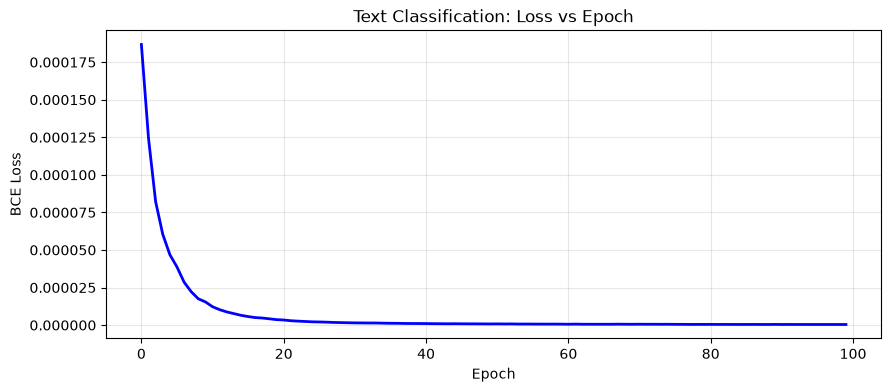

In [6]:
# 🔹 CELDA 5: Training Loop

import matplotlib.pyplot as plt

print("\n" + "=" * 60)
print("TRAINING: CLASIFICADOR DE SENTIMIENTOS")
print("=" * 60)

print("""
¿QUÉ HACE ESTA CELDA?
Entrena modelo en tweets.

PROCESO:
1. Forward: LSTM procesa tweet → predicción
2. Loss: Binary Cross-Entropy (comparar con true label)
3. Backward: Calcula gradientes
4. Update: Optimizer ajusta pesos
5. Repetir 100 epochs
""")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Mover modelo a dispositivo
model = model.to(device)

# Loss y optimizer
criterion = nn.BCELoss()  # Binary Cross-Entropy para clasificación binaria
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Preparar datos
X_train = X.to(device)
y_train = y.float().unsqueeze(1).to(device)  # (batch, 1)

# Training
epochs = 100
losses = []

print(f"\nEntrenando por {epochs} epochs...\n")

for epoch in range(epochs):
    # Forward pass
    predictions = model(X_train)
    loss = criterion(predictions, y_train)
    losses.append(loss.item())
    
    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{epochs}: Loss={loss.item():.4f}")

print(f"\n✅ Training complete!")
print(f"Loss inicial: {losses[0]:.4f}")
print(f"Loss final: {losses[-1]:.4f}")

# Graficar
plt.figure(figsize=(10, 4))
plt.plot(losses, 'b-', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.title('Text Classification: Loss vs Epoch')
plt.grid(True, alpha=0.3)
plt.show()



PREDICCIONES: CLASIFICACIÓN DE SENTIMIENTOS

¿QUÉ HACE ESTA CELDA?
Usa modelo entrenado para predecir sentimientos.
Clasifica si tweets son positivos o negativos.


📊 Resultados:
  Accuracy: 100.0%

🔍 Ejemplos:

  1. "me encanta este producto es increíble"
     Real: 😊 Positivo | Predicción: 😊 Positivo ✅
     Confianza: 100.00%

  2. "odio esto es lo peor"
     Real: 😞 Negativo | Predicción: 😞 Negativo ✅
     Confianza: 0.00%

  3. "excelente calidad muy recomendado"
     Real: 😊 Positivo | Predicción: 😊 Positivo ✅
     Confianza: 100.00%

  4. "terrible experiencia no vuelvo"
     Real: 😞 Negativo | Predicción: 😞 Negativo ✅
     Confianza: 0.00%

  5. "me gusta mucho compré dos más"
     Real: 😊 Positivo | Predicción: 😊 Positivo ✅
     Confianza: 100.00%


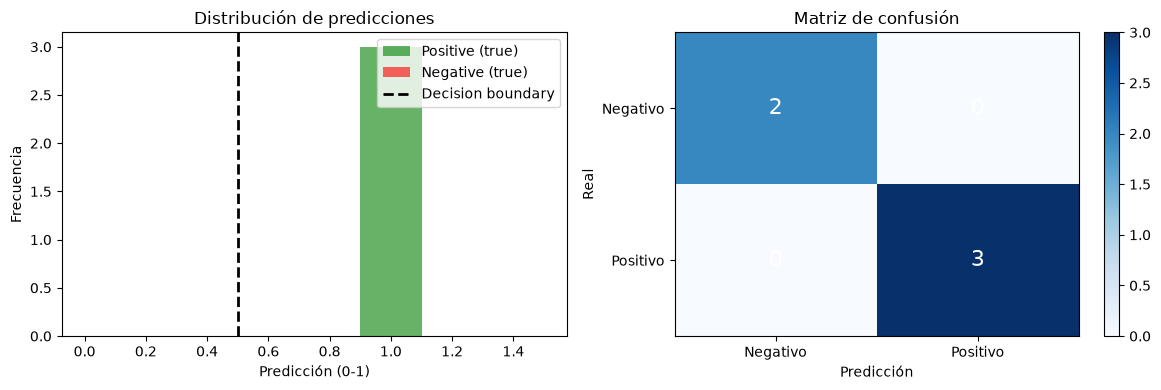


✅ Clasificador funcionando correctamente


In [7]:
# 🔹 CELDA 6: Predicciones y Evaluación

print("\n" + "=" * 60)
print("PREDICCIONES: CLASIFICACIÓN DE SENTIMIENTOS")
print("=" * 60)

print("""
¿QUÉ HACE ESTA CELDA?
Usa modelo entrenado para predecir sentimientos.
Clasifica si tweets son positivos o negativos.
""")

model.eval()

with torch.no_grad():
    predictions = model(X_train)
    predicted_labels = (predictions > 0.5).int().squeeze().cpu().numpy()

# Comparar predicciones vs reales
accuracy = (predicted_labels == labels).mean()

print(f"\n📊 Resultados:")
print(f"  Accuracy: {accuracy:.1%}")

print(f"\n🔍 Ejemplos:")
for i, (text, true_label, pred_prob) in enumerate(zip(texts, labels, predictions)):
    pred_label = 1 if pred_prob.item() > 0.5 else 0
    sentiment_true = "😊 Positivo" if true_label == 1 else "😞 Negativo"
    sentiment_pred = "😊 Positivo" if pred_label == 1 else "😞 Negativo"
    
    correct = "✅" if true_label == pred_label else "❌"
    
    print(f"\n  {i+1}. \"{text}\"")
    print(f"     Real: {sentiment_true} | Predicción: {sentiment_pred} {correct}")
    print(f"     Confianza: {pred_prob.item():.2%}")

# Visualizar predicciones
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma de predicciones
ax1 = axes[0]
pos_preds = predictions[torch.tensor(labels) == 1].cpu().numpy()
neg_preds = predictions[torch.tensor(labels) == 0].cpu().numpy()

ax1.hist(pos_preds, bins=5, alpha=0.6, label='Positive (true)', color='green')
ax1.hist(neg_preds, bins=5, alpha=0.6, label='Negative (true)', color='red')
ax1.axvline(0.5, color='black', linestyle='--', linewidth=2, label='Decision boundary')
ax1.set_xlabel('Predicción (0-1)')
ax1.set_ylabel('Frecuencia')
ax1.set_title('Distribución de predicciones')
ax1.legend()

# Matriz de confusión
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(labels, predicted_labels)

ax2 = axes[1]
im = ax2.imshow(cm, cmap='Blues', aspect='auto')
ax2.set_xlabel('Predicción')
ax2.set_ylabel('Real')
ax2.set_title('Matriz de confusión')
ax2.set_xticks([0, 1])
ax2.set_yticks([0, 1])
ax2.set_xticklabels(['Negativo', 'Positivo'])
ax2.set_yticklabels(['Negativo', 'Positivo'])

# Agregar números
for i in range(2):
    for j in range(2):
        ax2.text(j, i, cm[i, j], ha='center', va='center', color='white', fontsize=16)

plt.colorbar(im, ax=ax2)
plt.tight_layout()
plt.show()

print(f"\n✅ Clasificador funcionando correctamente")


In [8]:
# 🔹 CELDA 7: Resumen Semana 10

print("""
✅ SEMANA 10: NLP COMPLETADA

CONCEPTOS CLAVE APRENDIDOS:
✓ Tokenización: Texto → Palabras → Índices
✓ Embeddings: Índices → Vectores (significado)
✓ LSTM para textos: Procesa secuencias de palabras
✓ Clasificación: Binary (positivo/negativo)
✓ Sentiment analysis: Detectar emoción en texto

ARQUITECTURA:
Texto → Tokenización → Embeddings → LSTM → Clasificación

APLICACIONES NLP:
✓ Análisis de sentimientos (tweets, reviews)
✓ Clasificación de textos (spam/no spam, categorías)
✓ Traducción automática
✓ Q&A (question answering)
✓ Resumen de documentos

MES 1 + SEMANA 10 COMPLETADA

Dominas: Fundamentos + ML + DL + CNN + RNN + NLP

PRÓXIMAS SEMANAS:
- Semana 11: Transformers (ATENCIÓN - la revolución)
- Semana 12: LLMs + RAG (chatbots inteligentes)
""")



✅ SEMANA 10: NLP COMPLETADA

CONCEPTOS CLAVE APRENDIDOS:
✓ Tokenización: Texto → Palabras → Índices
✓ Embeddings: Índices → Vectores (significado)
✓ LSTM para textos: Procesa secuencias de palabras
✓ Clasificación: Binary (positivo/negativo)
✓ Sentiment analysis: Detectar emoción en texto

ARQUITECTURA:
Texto → Tokenización → Embeddings → LSTM → Clasificación

APLICACIONES NLP:
✓ Análisis de sentimientos (tweets, reviews)
✓ Clasificación de textos (spam/no spam, categorías)
✓ Traducción automática
✓ Q&A (question answering)
✓ Resumen de documentos

MES 1 + SEMANA 10 COMPLETADA

Dominas: Fundamentos + ML + DL + CNN + RNN + NLP

PRÓXIMAS SEMANAS:
- Semana 11: Transformers (ATENCIÓN - la revolución)
- Semana 12: LLMs + RAG (chatbots inteligentes)

